In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')

# Sesuaikan dengan path tempat kamu menyimpan file sebelumnya
path = '/content/drive/MyDrive/Colab Notebooks/bismillah lulus/'
file_input = path + 'dataset_heuristic.csv'

# Coba gunakan pemisah Tab (\t) karena tadi kita menyimpannya dengan format itu
# Jika masih error, kita tambahkan on_bad_lines untuk melewati baris yang rusak
try:
    df = pd.read_csv(file_input, sep='\t')
    print("Berhasil membaca dengan pemisah TAB")
except:
    df = pd.read_csv(file_input, sep=',')
    print("Berhasil membaca dengan pemisah KOMA")

# Jika tetap error karena ada baris yang formatnya berantakan di tengah (ParserError):
# df = pd.read_csv(file_input, sep='\t', on_bad_lines='skip')

print(f"Data Loaded: {len(df)} baris")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Berhasil membaca dengan pemisah TAB
Data Loaded: 75119 baris


,conv_id,line,author,text,label
0,001642060867dc1119343316fc21926c,1,8596c082ca02cf3d2e40682389f76a47,hi,0
1,001642060867dc1119343316fc21926c,2,4423d67017f371bb5b7218053f06def1,hi :),0
2,001642060867dc1119343316fc21926c,3,4423d67017f371bb5b7218053f06def1,how r u?,0
3,001642060867dc1119343316fc21926c,4,8596c082ca02cf3d2e40682389f76a47,wanna play on phone,0
4,001642060867dc1119343316fc21926c,5,4423d67017f371bb5b7218053f06def1,lolz i cant rite now,0


Jumlah Data per Label:
label
0    65317
1     9802
Name: count, dtype: int64

Persentase Data per Label (%):
label
0    86.95137
1    13.04863
Name: proportion, dtype: float64


/tmp/ipykernel_3832/3181500109.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


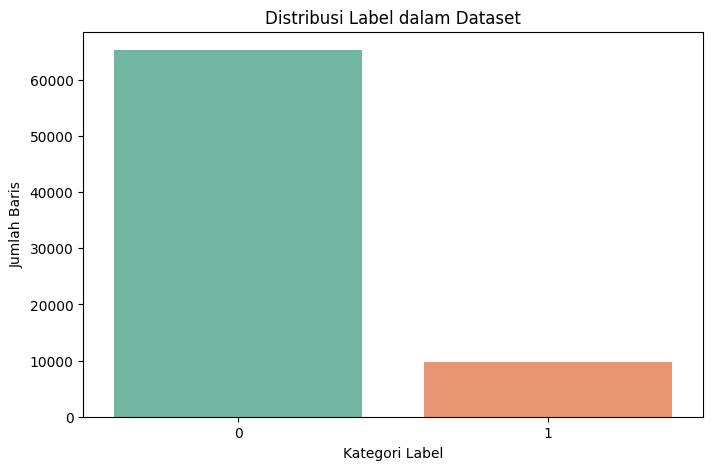

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menampilkan jumlah masing-masing label dalam bentuk angka
print("Jumlah Data per Label:")
print(df['label'].value_counts())

# 2. Menampilkan persentasenya
print("\nPersentase Data per Label (%):")
print(df['label'].value_counts(normalize=True) * 100)

# 3. Membuat visualisasi grafik batang (bar chart)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Distribusi Label dalam Dataset')
plt.xlabel('Kategori Label')
plt.ylabel('Jumlah Baris')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# --- 1. SPLIT CONV_ID TERLEBIH DAHULU (Anti-Nyontek) ---
unique_convs = df['conv_id'].unique()
train_convs, test_convs = train_test_split(unique_convs, test_size=0.2, random_state=42)

train_df_raw = df[df['conv_id'].isin(train_convs)].copy()
test_df_raw = df[df['conv_id'].isin(test_convs)].copy()

# --- 2. FUNGSI SLIDING WINDOW (Tetap Sama) ---
def create_best_windows(df_input, window_size=10, step_size=1): # Default diubah ke 3
    windowed_data = []
    grouped = df_input.groupby('conv_id')

    for conv_id, group in grouped:
        group = group.sort_values('line')
        texts = group['text'].astype(str).tolist()
        labels = group['label'].tolist()

        if len(texts) <= window_size:
            combined_text = " [SEP] ".join(texts)
            final_label = 1 if 1 in labels else 0
            windowed_data.append([conv_id, combined_text, final_label])
        else:
            # Pergeseran setiap 3 baris
            for i in range(0, len(texts) - window_size + 1, step_size):
                window_texts = texts[i : i + window_size]
                window_labels = labels[i : i + window_size]

                combined_text = " [SEP] ".join(window_texts)
                final_label = 1 if 1 in window_labels else 0
                windowed_data.append([conv_id, combined_text, final_label])

    return pd.DataFrame(windowed_data, columns=['conv_id', 'text', 'label'])

# --- 3. EKSEKUSI WINDOWING DENGAN STEP SIZE 3 ---
print("⏳ Membuat window dengan Step Size: 3...")
train_windowed = create_best_windows(train_df_raw, window_size=10, step_size=1)
test_windowed = create_best_windows(test_df_raw, window_size=10, step_size=1)

# --- 4. BALANCING (UNDERSAMPLING) ---
df_majority = train_windowed[train_windowed.label == 0]
df_minority = train_windowed[train_windowed.label == 1]

if len(df_majority) < len(df_minority):
    df_majority, df_minority = df_minority, df_majority

df_majority_downsampled = resample(df_majority,
                                 replace=False,
                                 n_samples=len(df_minority),
                                 random_state=42)

train_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1).reset_index(drop=True)

print("\n✅ Proses Selesai!")
print(f"Total baris Train (Balanced): {len(train_balanced)}")
print(f"Total baris Test (Murni): {len(test_windowed)}")
print("-" * 30)
print("Distribusi Label Baru:")
print(train_balanced['label'].value_counts())

⏳ Membuat window dengan Step Size: 3...

✅ Proses Selesai!
Total baris Train (Balanced): 38824
Total baris Test (Murni): 13926
------------------------------
Distribusi Label Baru:
label
1    19412
0    19412
Name: count, dtype: int64


In [ ]:
import re
import string

def clean_text(text):
    # 1. Pastikan teks adalah string
    text = str(text)

    # 2. Ubah ke huruf kecil (Case Folding)
    text = text.lower()

    # 3. Hapus URL/Link (sering muncul di chat predator)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 4. Hapus karakter non-ASCII (emoji, simbol aneh, karakter spesial)
    text = text.encode("ascii", "ignore").decode()

    # 5. Hapus tanda baca KECUALI kurung siku []
    # Penting: kita butuh [ ] agar token [SEP] tidak rusak
    punctuation_cleaned = string.punctuation.replace('[', '').replace(']', '')
    text = text.translate(str.maketrans('', '', punctuation_cleaned))

    # 6. Hapus spasi ganda atau spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# --- EKSEKUSI CLEANING ---
print("⏳ Sedang membersihkan teks... mohon tunggu sebentar.")

# 1. Bersihkan data Training
train_balanced['text_clean'] = train_balanced['text'].apply(clean_text)

# 2. Bersihkan data Testing
test_windowed['text_clean'] = test_windowed['text'].apply(clean_text)

print("✅ Cleaning selesai untuk Train dan Test set!")

# Intip perbandingan di data training
print("\nContoh hasil cleaning (Data Train):")
display(train_balanced[['text', 'text_clean']].head())

⏳ Sedang membersihkan teks... mohon tunggu sebentar.
✅ Cleaning selesai untuk Train dan Test set!

Contoh hasil cleaning (Data Train):


,text,text_clean
0,well if im not worth it then dont bother like ...,well if im not worth it then dont bother like ...
1,"ok [SEP] u gonna b dere rite??????? [SEP] yes,...",ok [sep] u gonna b dere rite [sep] yes ill b t...
2,brb gettin sum md [SEP] k [SEP] busy? [SEP] sr...,brb gettin sum md [sep] k [sep] busy [sep] sry...
3,'kk [SEP] it get weird 4 me to somtimes [SEP] ...,kk [sep] it get weird 4 me to somtimes [sep] [...
4,8 [SEP] m thinking [SEP] got 3 more days till ...,8 [sep] m thinking [sep] got 3 more days till ...


In [ ]:
!pip install -q transformers datasets torch accelerate

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset, DatasetDict
import numpy as np

# Cek GPU (Wajib muncul "cuda")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Menggunakan Device: {device}")

✅ Menggunakan Device: cuda


In [ ]:
# 1. Load Tokenizer
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Fungsi Tokenisasi
def tokenize_function(examples):
    return tokenizer(examples["text_clean"], padding="max_length", truncation=True, max_length=128)

# 3. Ubah Pandas ke HuggingFace Dataset
# Kita bagi train_balanced sedikit untuk validation agar Trainer tidak error
df_train_sub = train_balanced.sample(frac=0.9, random_state=42)
df_val_sub = train_balanced.drop(df_train_sub.index)

raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(df_train_sub),
    "validation": Dataset.from_pandas(df_val_sub),
    "test": Dataset.from_pandas(test_windowed) # Mengganti test_df dengan test_windowed
})

# 4. Jalankan Tokenisasi
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

# 5. Bersihkan kolom yang tidak perlu
tokenized_datasets = tokenized_datasets.remove_columns(["text_clean"])
# If "__index_level_0__" is not expected due to reset_index(drop=True), this block is unnecessary.
# if "__index_level_0__" in tokenized_datasets["train"].column_names:
#     tokenized_datasets = tokenized_datasets.remove_columns(["__index_level_0__"])

tokenized_datasets.set_format("torch")
print("✅ Tokenisasi Selesai!")

Map:   0%|          | 0/34942 [00:00<?, ? examples/s]

Map:   0%|          | 0/3882 [00:00<?, ? examples/s]

Map:   0%|          | 0/13926 [00:00<?, ? examples/s]

✅ Tokenisasi Selesai!


In [ ]:
!pip install -q evaluate
import numpy as np
from evaluate import load

# Load library evaluasi
metric_acc = load("accuracy")
metric_f1 = load("f1")
metric_precision = load("precision")
metric_recall = load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Hitung semua metrik
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=predictions, references=labels)["f1"]
    prec = metric_precision.compute(predictions=predictions, references=labels)["precision"]
    rec = metric_recall.compute(predictions=predictions, references=labels)["recall"]

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec
    }

# --- 1. Load Model (Tetap sama) ---
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2).to(device)

# --- 2. Atur Parameter Training (5 Epoch) ---
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1", # Model terbaik ditentukan dari F1 tertinggi
    report_to="none"
)

# --- 3. Inisialisasi Trainer (Masukkan compute_metrics) ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics # <--- PENTING: Masukkan fungsi metrik di sini
)

# --- 4. GAS TRAINING ---
print("🚀 Memulai Training BERT dengan Metrik Lengkap...")
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Memulai Training BERT dengan Metrik Lengkap...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.198924,0.191499,0.940495,0.941563,0.930965,0.952405
2,0.113100,0.146680,0.965997,0.966344,0.962907,0.969806
3,0.049170,0.135524,0.974755,0.974962,0.973469,0.976459


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6552, training_loss=0.15094143130403737, metrics={'train_runtime': 2552.6448, 'train_samples_per_second': 41.066, 'train_steps_per_second': 2.567, 'total_flos': 6895219872291840.0, 'train_loss': 0.15094143130403737, 'epoch': 3.0})

⏳ Menghitung prediksi pada data evaluasi...


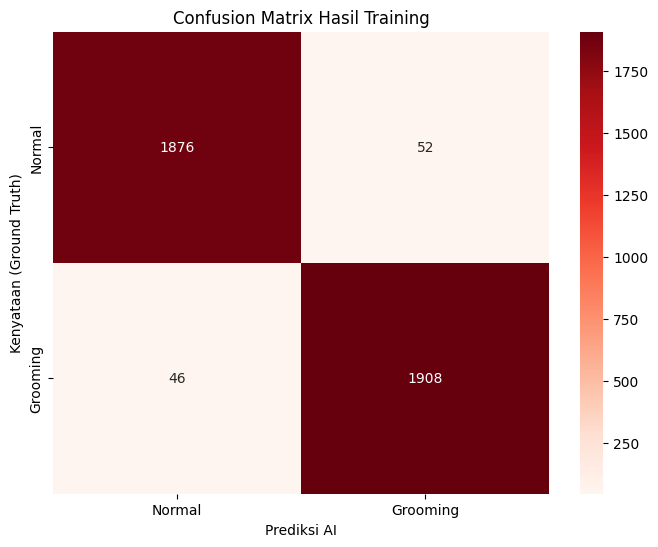


--- PERFORMANCE REPORT ---
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97      1928
    Grooming       0.97      0.98      0.97      1954

    accuracy                           0.97      3882
   macro avg       0.97      0.97      0.97      3882
weighted avg       0.97      0.97      0.97      3882



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader

def show_train_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    print("⏳ Menghitung prediksi pada data evaluasi...")

    with torch.no_grad():
        for batch in dataloader:
            # Pindahkan data ke GPU
            # Extract input_ids, attention_mask, and true labels from the batch
            input_ids = batch['input_ids'].to(model.device)
            attention_mask = batch['attention_mask'].to(model.device)
            true_labels = batch['label'].to(model.device) # Access 'label' key

            # Prepare inputs for the model (only input_ids and attention_mask needed for prediction)
            inputs = {
                'input_ids': input_ids,
                'attention_mask': attention_mask
            }
            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(true_labels.cpu().numpy())

    # 1. Hitung Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 2. Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Normal', 'Grooming'],
                yticklabels=['Normal', 'Grooming'])
    plt.xlabel('Prediksi AI')
    plt.ylabel('Kenyataan (Ground Truth)')
    plt.title('Confusion Matrix Hasil Training')
    plt.show()

    # 3. Print Report
    print("\n--- PERFORMANCE REPORT ---")
    print(classification_report(all_labels, all_preds, target_names=['Normal', 'Grooming']))

# Jalankan fungsi ini
# Tambahkan ini untuk membuat val_dataloader
val_dataloader = DataLoader(
    tokenized_datasets["validation"],
    batch_size=16, # Sesuaikan dengan per_device_eval_batch_size dari TrainingArguments
    shuffle=False
)

show_train_confusion_matrix(model, val_dataloader)

In [ ]:
!pip install deep_translator

In [ ]:
  from deep_translator import GoogleTranslator
  import torch
  import torch.nn.functional as F

  # 1. Inisialisasi Translator
  translator = GoogleTranslator(source='id', target='en')

  def detect_grooming_indo_final(chat_history, window_size=10, threshold=0.3):
      results = []
      model.eval()

      print(f"🕵️ Menganalisis {len(chat_history)} chat dengan jendela {window_size}...\n")

      for i in range(len(chat_history)):
          # Ambil konteks sliding window
          start = max(0, i - window_size + 1)
          context_chunk = " [SEP] ".join(chat_history[start:i+1])

          # 2. Terjemahkan menggunakan deep_translator
          try:
              # Tetap gunakan trik penggantian kata untuk akurasi nuansa
              text_to_process = context_chunk.replace("berani", "vulgar/nude").replace("rahasia kita", "our secret, don't tell parents")
              translated = translator.translate(text_to_process)
          except Exception as e:
              print(f"Error translasi: {e}")
              translated = context_chunk

          # 3. Tokenisasi & Prediksi
          inputs = tokenizer(translated, return_tensors="pt", padding=True, truncation=True, max_length=512).to(model.device)

          with torch.no_grad():
              outputs = model(**inputs)
              probs = F.softmax(outputs.logits, dim=-1)

              # Ambil skor Grooming (Asumsi Label 1 = Grooming)
              prob_grooming = probs[0][1].item()

          # 4. Penentuan Label berdasarkan Threshold
          label = "GROOMING" if prob_grooming >= threshold else "NORMAL"

          results.append({
              'chat': chat_history[i],
              'label': label,
              'prob': prob_grooming
          })

      return results

  # --- DATA TES ---
  percakapan = [
    "Halo cantik, kamu kelihatan dewasa sekali hari ini.",
      "Lagi sendirian ya di rumah? Mama papa pergi?",
      "Aku mau kasih hadiah rahasia buat kamu.",
      "Tapi janji ya jangan bilang mama kalau kita chat.",
      "Ini rahasia antara kita berdua saja ya sayang.",
      "Jangan kasih tahu orang tua atau teman kamu.",
      "Aku kirim uang sekarang kalau kamu mau nurut.",
      "Coba kirim foto tanpa baju kamu ke aku sekarang.",
      "Nanti aku kasih kado yang lebih mahal lagi.",
      "Ingat, jangan sampai ada yang tahu rahasia ini."
  ]
  # Jalankan
  hasil = detect_grooming_indo_final(percakapan, window_size=10, threshold=0.3)

  # --- TAMPILKAN HASIL ---
  print(f"{'STATUS':<12} | {'SKOR':<6} | {'CHAT'}")
  print("-" * 70)
  for r in hasil:
      status = "🔴 GROOMING" if r['label'] == "GROOMING" else "🟢 NORMAL"
      print(f"{status:<12} | {r['prob']*100:>5.1f}% | {r['chat']}")

🕵️ Menganalisis 10 chat dengan jendela 10...

STATUS       | SKOR   | CHAT
----------------------------------------------------------------------
🔴 GROOMING   | 100.0% | Halo cantik, kamu kelihatan dewasa sekali hari ini.
🔴 GROOMING   | 100.0% | Lagi sendirian ya di rumah? Mama papa pergi?
🔴 GROOMING   | 100.0% | Aku mau kasih hadiah rahasia buat kamu.
🔴 GROOMING   | 100.0% | Tapi janji ya jangan bilang mama kalau kita chat.
🔴 GROOMING   | 100.0% | Ini rahasia antara kita berdua saja ya sayang.
🔴 GROOMING   | 100.0% | Jangan kasih tahu orang tua atau teman kamu.
🔴 GROOMING   | 100.0% | Aku kirim uang sekarang kalau kamu mau nurut.
🔴 GROOMING   | 100.0% | Coba kirim foto tanpa baju kamu ke aku sekarang.
🔴 GROOMING   | 100.0% | Nanti aku kasih kado yang lebih mahal lagi.
🔴 GROOMING   | 100.0% | Ingat, jangan sampai ada yang tahu rahasia ini.


In [ ]:
  from deep_translator import GoogleTranslator
  import torch
  import torch.nn.functional as F

  # 1. Inisialisasi Translator
  translator = GoogleTranslator(source='id', target='en')

  def detect_grooming_indo_final(chat_history, window_size=10, threshold=0.3):
      results = []
      model.eval()

      print(f"🕵️ Menganalisis {len(chat_history)} chat dengan jendela {window_size}...\n")

      for i in range(len(chat_history)):
          # Ambil konteks sliding window
          start = max(0, i - window_size + 1)
          context_chunk = " [SEP] ".join(chat_history[start:i+1])

          # 2. Terjemahkan menggunakan deep_translator
          try:
              # Tetap gunakan trik penggantian kata untuk akurasi nuansa
              text_to_process = context_chunk.replace("berani", "vulgar/nude").replace("rahasia kita", "our secret, don't tell parents")
              translated = translator.translate(text_to_process)
          except Exception as e:
              print(f"Error translasi: {e}")
              translated = context_chunk

          # 3. Tokenisasi & Prediksi
          inputs = tokenizer(translated, return_tensors="pt", padding=True, truncation=True, max_length=512).to(model.device)

          with torch.no_grad():
              outputs = model(**inputs)
              probs = F.softmax(outputs.logits, dim=-1)

              # Ambil skor Grooming (Asumsi Label 1 = Grooming)
              prob_grooming = probs[0][1].item()

          # 4. Penentuan Label berdasarkan Threshold
          label = "GROOMING" if prob_grooming >= threshold else "NORMAL"

          results.append({
              'chat': chat_history[i],
              'label': label,
              'prob': prob_grooming
          })

      return results

  # --- DATA TES ---
  percakapan = [
    "Halo dek, salam kenal ya.",
    "Kakak punya hadiah lho buat kamu, tapi ini rahasia kita berdua aja ya.",
    "Jangan kasih tahu orang tua atau teman kamu dulu, biar seru.",
    "Di rumah lagi ada siapa dek? Mama papa lagi pergi ya?",
    "Kalau rumah sepi, kakak boleh ke sana sekarang?",
    "Kita main di kamar kamu aja biar gak ketahuan."
  ]
  # Jalankan
  hasil = detect_grooming_indo_final(percakapan, window_size=10, threshold=0.3)

  # --- TAMPILKAN HASIL ---
  print(f"{'STATUS':<12} | {'SKOR':<6} | {'CHAT'}")
  print("-" * 70)
  for r in hasil:
      status = "🔴 GROOMING" if r['label'] == "GROOMING" else "🟢 NORMAL"
      print(f"{status:<12} | {r['prob']*100:>5.1f}% | {r['chat']}")

🕵️ Menganalisis 6 chat dengan jendela 10...

STATUS       | SKOR   | CHAT
----------------------------------------------------------------------
🔴 GROOMING   |  93.0% | Halo dek, salam kenal ya.
🔴 GROOMING   |  91.0% | Kakak punya hadiah lho buat kamu, tapi ini rahasia kita berdua aja ya.
🔴 GROOMING   |  94.4% | Jangan kasih tahu orang tua atau teman kamu dulu, biar seru.
🔴 GROOMING   |  42.2% | Di rumah lagi ada siapa dek? Mama papa lagi pergi ya?
🟢 NORMAL     |  19.1% | Kalau rumah sepi, kakak boleh ke sana sekarang?
🔴 GROOMING   |  97.5% | Kita main di kamar kamu aja biar gak ketahuan.


In [ ]:
import torch
import re
import string
import torch.nn.functional as F
from deep_translator import GoogleTranslator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = text.encode("ascii", "ignore").decode()
    punctuation_cleaned = string.punctuation.replace('[', '').replace(']', '')
    text = text.translate(str.maketrans('', '', punctuation_cleaned))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def predict_single_sentence(sentence):
    # 1. Terjemahkan dari Indo ke Inggris (Wajib karena model dilatih pakai dataset Inggris)
    try:
        translated_text = GoogleTranslator(source='id', target='en').translate(sentence)
    except Exception as e:
        print(f"Error Translasi: {e}")
        translated_text = sentence # Fallback ke teks asli jika gagal

    # 2. Pastikan model dalam mode evaluasi
    model.eval()

    # 3. Bersihkan teks (Gunakan fungsi clean_text yang sudah ada di notebook sebelumnya)
    cleaned_sentence = clean_text(translated_text)

    # 4. Tokenisasi
    inputs = tokenizer(
        cleaned_sentence,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    ).to(device)

    # 5. Prediksi (Inference)
    with torch.no_grad():
        outputs = model(**inputs)
        # Ambil probabilitas menggunakan Softmax
        probs = F.softmax(outputs.logits, dim=-1)

        # probs[0][1] adalah probabilitas Grooming/Danger
        danger_score = probs[0][1].item()
        normal_score = probs[0][0].item()

    # 6. Tentukan Status
    status = "🚨 BAHAYA (Predator)" if danger_score > 0.5 else "✅ AMAN (Normal)"

    print(f"Kalimat Input : '{sentence}'")
    print(f"Terjemahan    : '{translated_text}'")
    print(f"Skor Bahaya   : {danger_score:.4f} ({danger_score*100:.2f}%)")
    print(f"Skor Aman     : {normal_score:.4f} ({normal_score*100:.2f}%)")
    print(f"Kesimpulan    : {status}")
    print("-" * 50)

# --- CONTOH PENGGUNAAN ---
print("🔍 HASIL DETEKSI SETELAH PENAMBAHAN DATA SINTETIS:\n")

# Uji kalimat yang tadinya False Positive (Harusnya Aman)
predict_single_sentence("Kalau rumah sepi, kakak boleh ke sana sekarang?")

# Uji kalimat yang mengandung manipulasi (Harusnya Bahaya)
predict_single_sentence("Aku sayang kamu, tapi ini rahasia kita berdua ya jangan bilang mama")

# Uji kalimat santai lainnya
predict_single_sentence("Hati-hati di jalan ya sayang, kabari kalau sudah sampai")

🔍 HASIL DETEKSI SETELAH PENAMBAHAN DATA SINTETIS:

Kalimat Input : 'Kalau rumah sepi, kakak boleh ke sana sekarang?'
Terjemahan    : 'If the house is quiet, can you go there now?'
Skor Bahaya   : 0.0039 (0.39%)
Skor Aman     : 0.9961 (99.61%)
Kesimpulan    : ✅ AMAN (Normal)
--------------------------------------------------
Kalimat Input : 'Aku sayang kamu, tapi ini rahasia kita berdua ya jangan bilang mama'
Terjemahan    : 'I love you, but this is a secret between the two of us, so don't tell mom'
Skor Bahaya   : 0.9998 (99.98%)
Skor Aman     : 0.0002 (0.02%)
Kesimpulan    : 🚨 BAHAYA (Predator)
--------------------------------------------------
Kalimat Input : 'Hati-hati di jalan ya sayang, kabari kalau sudah sampai'
Terjemahan    : 'Be careful on the road, darling, let me know when you arrive'
Skor Bahaya   : 0.0046 (0.46%)
Skor Aman     : 0.9954 (99.54%)
Kesimpulan    : ✅ AMAN (Normal)
--------------------------------------------------


In [ ]:
# Tentukan nama folder tempat menyimpan
save_directory = "model6"

# Simpan Model
model.save_pretrained(save_directory)

# Simpan Tokenizer (sangat penting agar cara potong katanya tetap sama)
tokenizer.save_pretrained(save_directory)

print(f"✅ Model berhasil disimpan di folder: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model berhasil disimpan di folder: model6


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Simpan ke Drive
model.save_pretrained('/content/drive/MyDrive/Colab Notebooks/bismillah lulus/model6')
tokenizer.save_pretrained('/content/drive/MyDrive/Colab Notebooks/bismillah lulus/model6')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/bismillah lulus/model6/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/bismillah lulus/model6/tokenizer.json')